In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
trades = pd.read_csv('/Users/sumanthmarcos/Documents/PROJECTS/Trader Behavior Analysis/data/historical_data.csv')
sentiment = pd.read_csv('/Users/sumanthmarcos/Documents/PROJECTS/Trader Behavior Analysis/data/fear_greed_index.csv')

In [57]:
print(trades.head())
print(trades.columns)

print(sentiment.head())
print(sentiment.columns)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [58]:
trades.columns = trades.columns.str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.replace(' ', '_')

In [59]:
trades['Timestamp_IST'] = pd.to_datetime(trades['Timestamp_IST'], errors='coerce')
trades['date'] = trades['Timestamp_IST'].dt.normalize()

In [60]:
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], unit='s', errors='coerce')
sentiment['date'] = sentiment['timestamp'].dt.normalize()

In [61]:
print(trades['date'].dtype)
print(sentiment['date'].dtype)

datetime64[ns]
datetime64[ns]


In [62]:
merged = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [63]:
merged[['date','classification']].head()

,date,classification
0,2024-02-12,Greed
1,2024-02-12,Greed
2,2024-02-12,Greed
3,2024-02-12,Greed
4,2024-02-12,Greed


In [64]:
merged.head()

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Timestamp_IST,Start_Position,Direction,Closed_PnL,Transaction_Hash,Order_ID,Crossed,Fee,Trade_ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [65]:
merged['classification'].value_counts()

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

In [66]:
merged.groupby('classification')['Closed_PnL'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,2326.0,1.891632,76.727713,-1430.889856,0.0,0.00000,0.298102,2020.000000
Extreme Greed,5621.0,205.816345,1861.557119,-18360.670070,0.0,0.96048,30.153710,44223.451870
Fear,13869.0,128.287950,1342.348497,-19841.240140,0.0,0.00000,8.201820,71535.716740
Greed,11292.0,53.988003,1399.468182,-117990.104100,0.0,0.00000,13.441364,34903.817100
Neutral,2756.0,27.088803,142.945889,-1032.981540,0.0,0.00000,9.267691,2979.554311


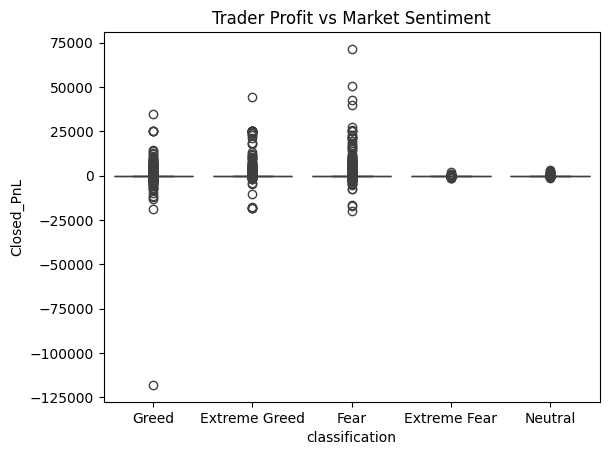

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed_PnL', data=merged)
plt.title("Trader Profit vs Market Sentiment")
plt.show()

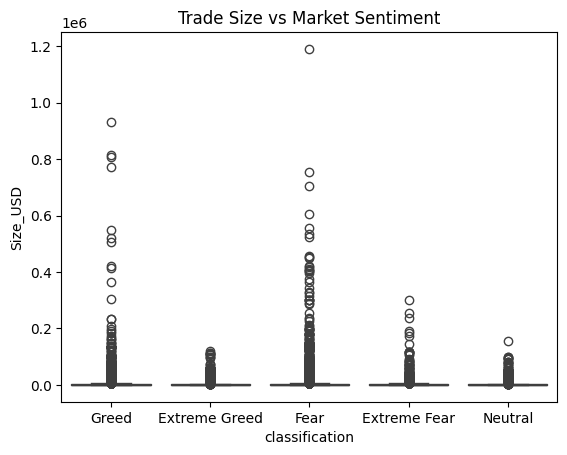

In [68]:
sns.boxplot(x='classification', y='Size_USD', data=merged)
plt.title("Trade Size vs Market Sentiment")
plt.show()

In [69]:
pd.crosstab(merged['classification'], merged['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736


In [70]:
top_traders = merged.groupby('Account')['Closed_PnL'].sum().sort_values(ascending=False)
top_traders.head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed_PnL, dtype: float64